# 04 — Exploratory Data Analysis (EDA)
## Drebin v1 · Static Feature Dataset

**Mục tiêu:**
- Load và khám phá dataset Drebin v1 (215 features, ~15K mẫu)
- Phân tích phân phối nhãn: Benign (B) vs Malware (S)
- Thống kê tần suất permissions nhạy cảm theo nhóm
- Xác định API calls thường bị lạm dụng bởi mã độc
- Đánh giá tương quan giữa các đặc trưng quan trọng

## 1. Setup

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# ── Đường dẫn ──────────────────────────────────────────────────────────────
BASE_DIR     = Path(r'H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020')
DREBIN_CSV   = BASE_DIR / 'csv' / 'drebin' / 'Drebin_v1.csv'
FEAT_CAT_CSV = BASE_DIR / 'csv' / 'drebin' / 'Dataset-features-categories.csv'
FIG_DIR      = BASE_DIR / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Mapping nhãn
CLASS_NAMES = {'B': 'Benign', 'S': 'Malware'}
CLASS_COLORS = {'Benign': '#3fb950', 'Malware': '#f85149'}

print(f'Drebin CSV : {DREBIN_CSV}')
print(f'Feature Cat: {FEAT_CAT_CSV}')
print(f'Figures    : {FIG_DIR}')

Drebin CSV : H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\csv\drebin\Drebin_v1.csv
Feature Cat: H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\csv\drebin\Dataset-features-categories.csv
Figures    : H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020\notebooks\figures


## 2. Load dữ liệu

Drebin v1: **215 đặc trưng nhị phân** (0/1) — permissions, API calls, intents, system commands.  
Dataset nhỏ (~15K rows) nên load trực tiếp từ CSV, không cần parquet.

In [10]:
# Load Drebin CSV
df = pd.read_csv(DREBIN_CSV)
print(f'Shape: {df.shape}')
print(f'Columns (first 5): {list(df.columns[:5])}')
print(f'Last column (label): {df.columns[-1]}')
print(f'\nLabel distribution:\n{df["class"].value_counts()}')

LABEL_COL = 'class'
X_raw = df.drop(columns=[LABEL_COL])
y_raw = df[LABEL_COL].map(CLASS_NAMES)     # 'B' -> 'Benign', 'S' -> 'Malware'

# Ép kiểu numeric — một số ô có giá trị '?' → coerce thành NaN → fillna(0)
X_raw = X_raw.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'\nSamples     : {len(df):,}')
print(f'Features    : {X_raw.shape[1]}')
print(f'Benign (B)  : {(df[LABEL_COL]=="B").sum():,}')
print(f'Malware (S) : {(df[LABEL_COL]=="S").sum():,}')
q_count = (df.drop(columns=[LABEL_COL]) == '?').sum().sum()
print(f'Gia tri "?" : {q_count} o (da doi thanh 0)')
print(f'NaN sau fix : {X_raw.isna().sum().sum()}')

Shape: (15036, 216)
Columns (first 5): ['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection']
Last column (label): class

Label distribution:
class
B    9476
S    5560
Name: count, dtype: int64

Samples     : 15,036
Features    : 215
Benign (B)  : 9,476
Malware (S) : 5,560
Gia tri "?" : 5 o (da doi thanh 0)
NaN sau fix : 0


In [11]:
# Load feature categories
feat_cat = pd.read_csv(FEAT_CAT_CSV, header=None, names=['feature', 'category'])
# Bỏ dòng cuối (nhãn 'class')
feat_cat = feat_cat[feat_cat['feature'] != 'class'].copy()
print(f'Feature categories loaded: {len(feat_cat)} features')
print(feat_cat['category'].value_counts())

Feature categories loaded: 215 features
category
Manifest Permission    113
API call signature      73
Intent                  23
Commands signature       6
Name: count, dtype: int64


## 3. Phân phối nhãn

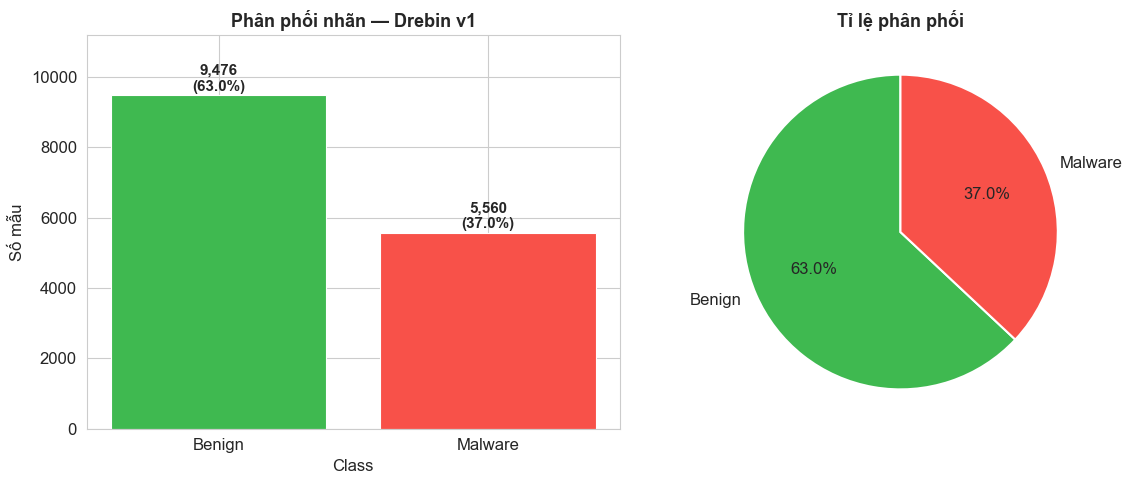

Imbalance ratio: 1.70x


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = y_raw.value_counts()
colors = [CLASS_COLORS[c] for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 50, f'{val:,}\n({val/len(y_raw)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Phân phối nhãn — Drebin v1', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Số mẫu')
axes[0].set_ylim(0, counts.max() * 1.18)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 12})
axes[1].set_title('Tỉ lệ phân phối', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '11_drebin_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {counts.max()/counts.min():.2f}x')

## 4. Phân nhóm đặc trưng

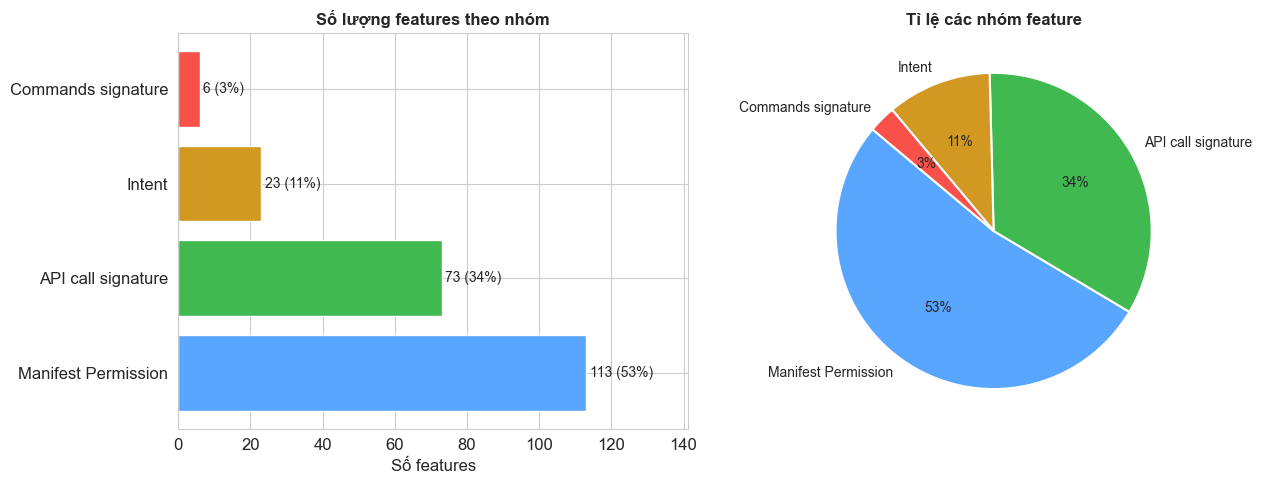

category
Manifest Permission    113
API call signature      73
Intent                  23
Commands signature       6


In [13]:
# Phân bố theo nhóm category
cat_counts = feat_cat['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_colors = ['#58a6ff', '#3fb950', '#d29922', '#f85149', '#bc8cff']
bars = axes[0].barh(cat_counts.index, cat_counts.values,
                    color=bar_colors[:len(cat_counts)], edgecolor='white')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(feat_cat)*100:.0f}%)',
                 va='center', fontsize=10)
axes[0].set_title('Số lượng features theo nhóm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số features')
axes[0].set_xlim(0, cat_counts.max() * 1.25)

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=bar_colors[:len(cat_counts)],
            autopct='%1.0f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 10})
axes[1].set_title('Tỉ lệ các nhóm feature', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '12_drebin_feature_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_counts.to_string())

## 5. Phân tích Permissions nhạy cảm

Tính tần suất xuất hiện (tỉ lệ %) của từng permission trong nhóm **Malware** và **Benign**.  
Permissions nào có sự chênh lệch lớn giữa 2 nhóm → đặc trưng phân biệt mạnh.

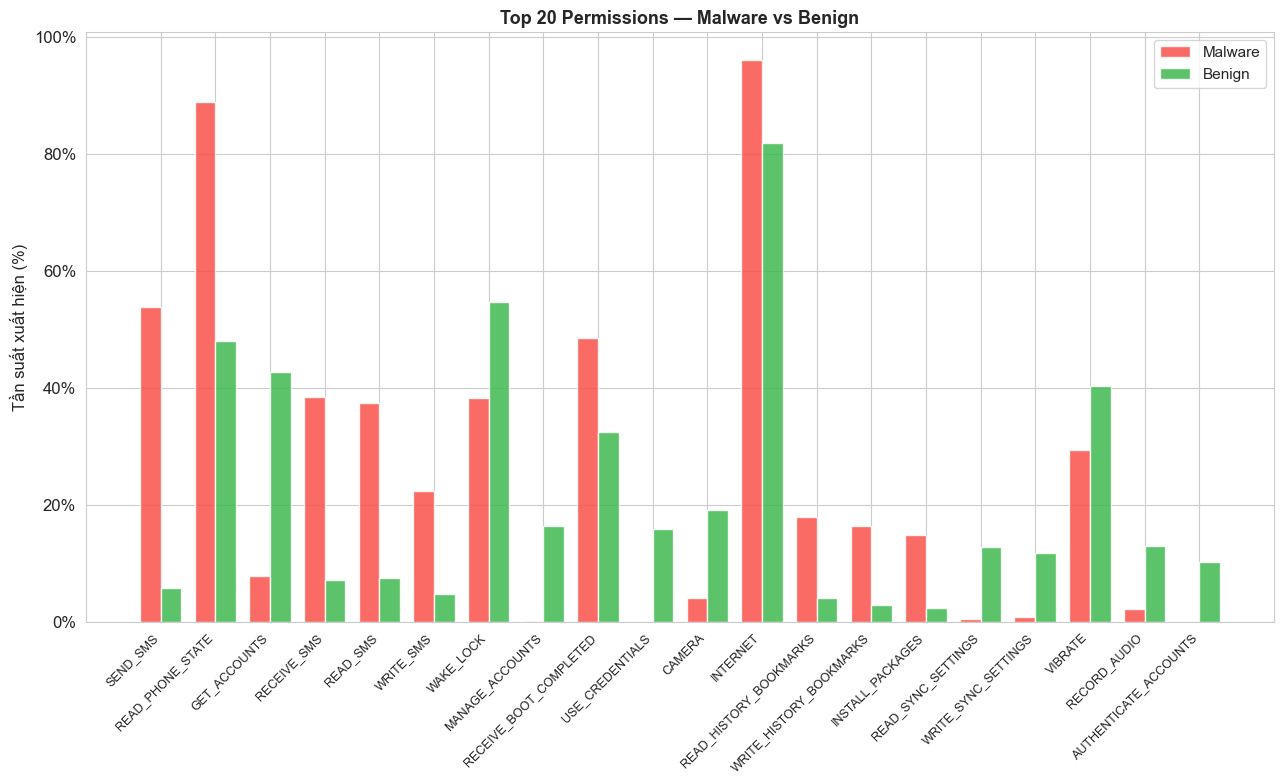


Top 5 permissions phân biệt mạnh nhất:
                  Malware (%)  Benign (%)  diff
SEND_SMS                 53.9         5.9  48.0
READ_PHONE_STATE         89.0        48.2  40.8
GET_ACCOUNTS              8.0        42.7  34.8
RECEIVE_SMS              38.5         7.1  31.3
READ_SMS                 37.5         7.6  29.9


In [14]:
# Lấy danh sách permission features
perm_features = feat_cat[feat_cat['category'] == 'Manifest Permission']['feature'].tolist()
perm_features = [f for f in perm_features if f in X_raw.columns]

df_perm = X_raw[perm_features].copy()
df_perm['label'] = y_raw.values

malware_mask = df_perm['label'] == 'Malware'
benign_mask  = df_perm['label'] == 'Benign'

mal_rate = df_perm[malware_mask][perm_features].mean() * 100
ben_rate = df_perm[benign_mask][perm_features].mean() * 100

perm_df = pd.DataFrame({'Malware (%)': mal_rate, 'Benign (%)': ben_rate})
perm_df['diff'] = (perm_df['Malware (%)'] - perm_df['Benign (%)']).abs()
perm_df = perm_df.sort_values('diff', ascending=False)

# Top 20 permissions có độ chênh lệch cao nhất
TOP_N = 20
top_perms = perm_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(13, 8))
x = np.arange(len(top_perms))
w = 0.38
bars1 = ax.bar(x - w/2, top_perms['Malware (%)'], w, label='Malware', color='#f85149', alpha=0.85)
bars2 = ax.bar(x + w/2, top_perms['Benign (%)'],  w, label='Benign',  color='#3fb950', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_perms.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Tần suất xuất hiện (%)')
ax.set_title(f'Top {TOP_N} Permissions — Malware vs Benign', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(FIG_DIR / '13_drebin_sensitive_permissions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nTop 5 permissions phân biệt mạnh nhất:')
print(top_perms[['Malware (%)', 'Benign (%)', 'diff']].head(5).to_string(float_format='%.1f'))

## 6. API Calls bị lạm dụng bởi Malware

Tương tự permissions, tính tần suất xuất hiện của các **API call signatures** trong nhóm Malware vs Benign.

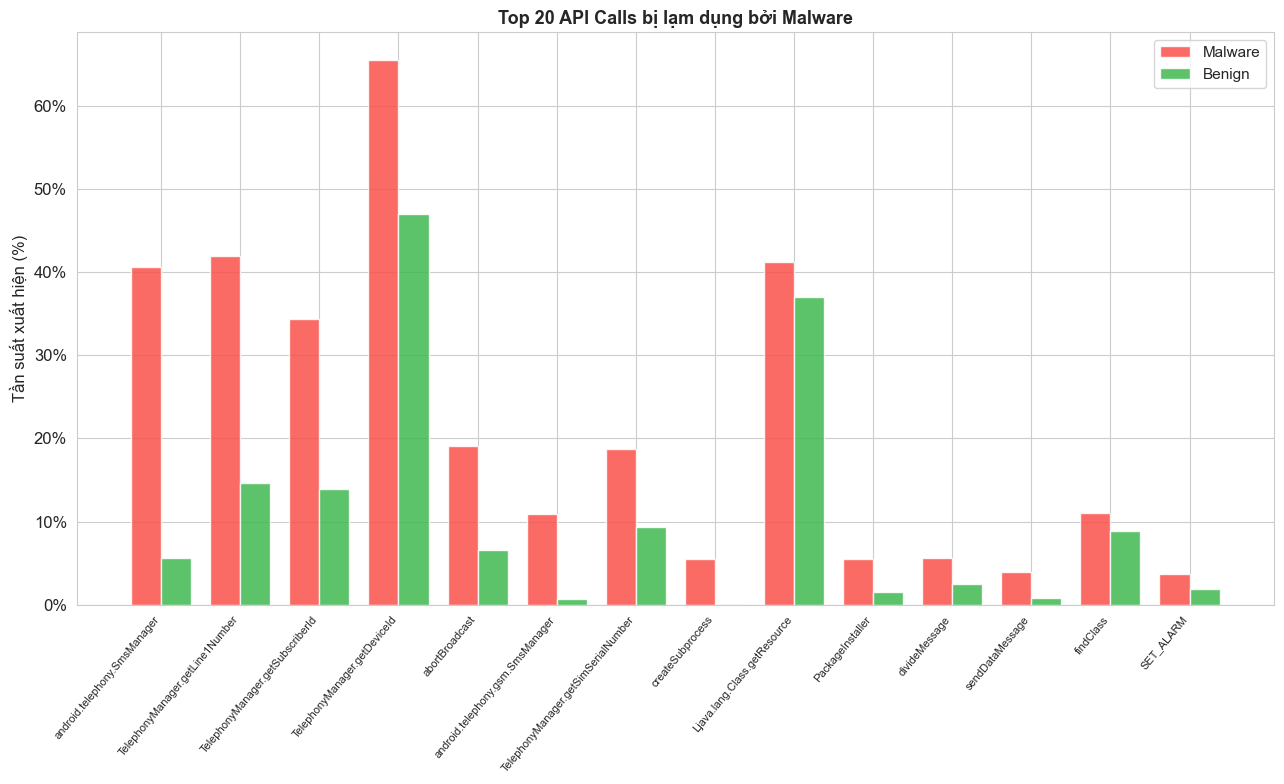


Top 5 API calls bị lạm dụng nhiều nhất:
                                  Malware (%)  Benign (%)  diff
android.telephony.SmsManager             40.6         5.6  35.0
TelephonyManager.getLine1Number          42.0        14.7  27.3
TelephonyManager.getSubscriberId         34.4        13.9  20.5
TelephonyManager.getDeviceId             65.6        47.1  18.5
abortBroadcast                           19.1         6.6  12.5


In [15]:
# Lấy danh sách API call features
api_features = feat_cat[feat_cat['category'] == 'API call signature']['feature'].tolist()
api_features = [f for f in api_features if f in X_raw.columns]

df_api = X_raw[api_features].copy()
df_api['label'] = y_raw.values

mal_api = df_api[df_api['label'] == 'Malware'][api_features].mean() * 100
ben_api = df_api[df_api['label'] == 'Benign'][api_features].mean() * 100

api_df = pd.DataFrame({'Malware (%)': mal_api, 'Benign (%)': ben_api})
api_df['diff'] = api_df['Malware (%)'] - api_df['Benign (%)']
# Chỉ lấy APIs bị lạm dụng nhiều hơn trong Malware (diff > 0)
api_df = api_df[api_df['diff'] > 0].sort_values('diff', ascending=False)

TOP_API = 20
top_apis = api_df.head(TOP_API)

fig, ax = plt.subplots(figsize=(13, 8))
x = np.arange(len(top_apis))
w = 0.38
ax.bar(x - w/2, top_apis['Malware (%)'], w, label='Malware', color='#f85149', alpha=0.85)
ax.bar(x + w/2, top_apis['Benign (%)'],  w, label='Benign',  color='#3fb950', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_apis.index, rotation=50, ha='right', fontsize=8)
ax.set_ylabel('Tần suất xuất hiện (%)')
ax.set_title(f'Top {TOP_API} API Calls bị lạm dụng bởi Malware', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(FIG_DIR / '14_drebin_api_calls_abused.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 5 API calls bị lạm dụng nhiều nhất:')
print(top_apis[['Malware (%)', 'Benign (%)', 'diff']].head(5).to_string(float_format='%.1f'))

## 7. Correlation Heatmap — Top Features

Tính ma trận tương quan Pearson cho top features theo **variance** (loại bỏ features quá đồng nhất).  
Đây là cơ sở để Stage 2 của feature selection (loại redundant features).

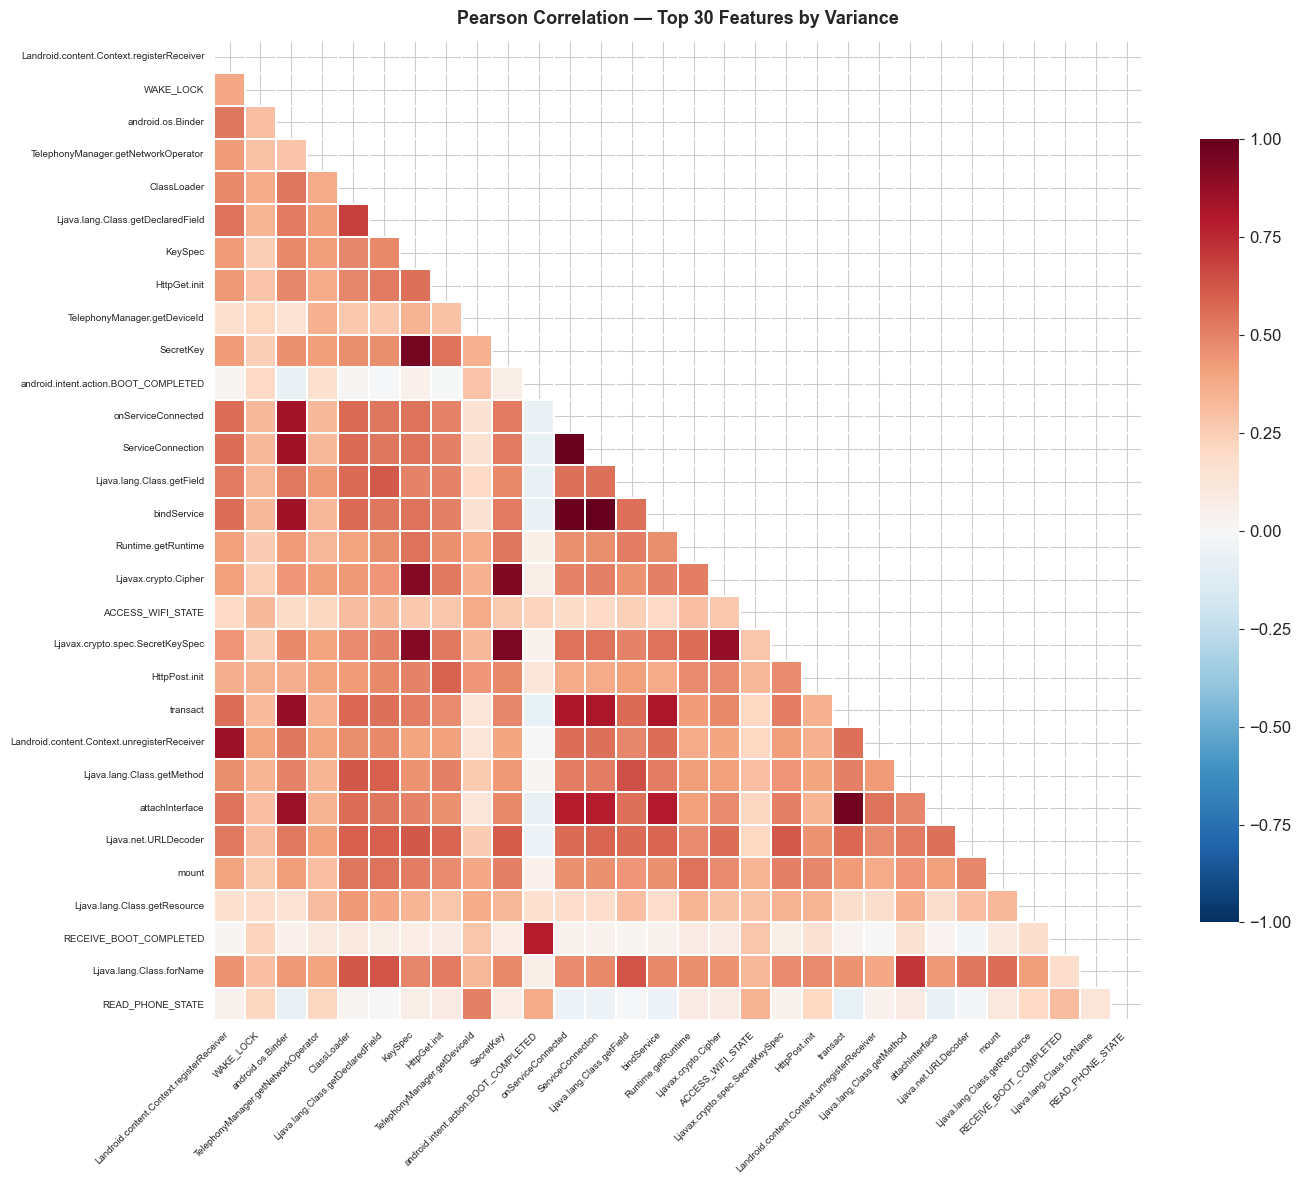

Số cặp features có |r| > 0.8: 19 / 900 (2.1%)


In [16]:
# Top N features theo variance
X_num = X_raw.select_dtypes(include='number')
variances = X_num.var()
TOP_VAR = 30
top_var_feats = variances.nlargest(TOP_VAR).index.tolist()

corr_mat = X_num[top_var_feats].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # ẩn tam giác trên

sns.heatmap(
    corr_mat,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
ax.set_title(f'Pearson Correlation — Top {TOP_VAR} Features by Variance',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / '15_drebin_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Tỉ lệ cặp có tương quan cao (|r| > 0.8)
flat = corr_mat.where(~mask).stack()
high_corr = (flat.abs() > 0.8).sum()
print(f'Số cặp features có |r| > 0.8: {high_corr} / {len(flat)} ({high_corr/len(flat)*100:.1f}%)')

## 8. EDA Summary

In [17]:
print('=' * 55)
print('  EDA Summary — Drebin v1 Static Features')
print('=' * 55)
print(f'  Số APK (samples)     : {len(df):,}')
print(f'  Số features          : {X_raw.shape[1]}')
print(f'  Benign (B)           : {(df["class"]=="B").sum():,} ({(df["class"]=="B").mean()*100:.1f}%)')
print(f'  Malware (S)          : {(df["class"]=="S").sum():,} ({(df["class"]=="S").mean()*100:.1f}%)')
print(f'  Imbalance ratio      : {y_raw.value_counts().max()/y_raw.value_counts().min():.2f}x')
print(f'  NaN count            : {df.isna().sum().sum()} (binary data)')
print(f'  Feature groups       :')
for cat, cnt in feat_cat['category'].value_counts().items():
    print(f'    {cat:<30}: {cnt}')
print('=' * 55)
print('  Bước tiếp theo → 05_pipeline_drebin.ipynb')
print('  RRFS + Train RF/SVM/KNN/NB/MLP/XGB + Stratified 5-Fold CV')
print('=' * 55)

  EDA Summary — Drebin v1 Static Features
  Số APK (samples)     : 15,036
  Số features          : 215
  Benign (B)           : 9,476 (63.0%)
  Malware (S)          : 5,560 (37.0%)
  Imbalance ratio      : 1.70x
  NaN count            : 0 (binary data)
  Feature groups       :
    Manifest Permission           : 113
    API call signature            : 73
    Intent                        : 23
    Commands signature            : 6
  Bước tiếp theo → 05_pipeline_drebin.ipynb
  RRFS + Train RF/SVM/KNN/NB/MLP/XGB + Stratified 5-Fold CV


In [ ]:
# Top intents / commands xuất hiện thường xuyên trong malware
malware_only = X_raw[y_raw == 'Malware']

# Tìm category theo từ khóa để tránh phụ thuộc tuyệt đối vào tên category
intent_features = feat_cat[
    feat_cat['category'].str.contains('intent', case=False, na=False)
]['feature'].tolist()
command_features = feat_cat[
    feat_cat['category'].str.contains('command', case=False, na=False)
]['feature'].tolist()

# Chỉ giữ feature thật sự có trong dữ liệu
intent_features = [f for f in intent_features if f in X_raw.columns]
command_features = [f for f in command_features if f in X_raw.columns]

if not intent_features:
    print('Khong tim thay intent feature trong feat_cat.')
else:
    top_5_intents = (
        malware_only[intent_features].mean() * 100
    ).sort_values(ascending=False).head(5)

    print('Top 5 intents xuat hien nhieu nhat trong malware (%):')
    display(top_5_intents.rename('Malware (%)').to_frame())

if not command_features:
    print('Khong tim thay command feature trong feat_cat.')
else:
    top_3_commands = (
        malware_only[command_features].mean() * 100
    ).sort_values(ascending=False).head(3)

    print('Top 3 commands xuat hien nhieu nhat trong malware (%):')
    display(top_3_commands.rename('Malware (%)').to_frame())